<a href="https://colab.research.google.com/github/Tejeshwini89/Computer-Vision/blob/main/Image%20and%20Video%20Operations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

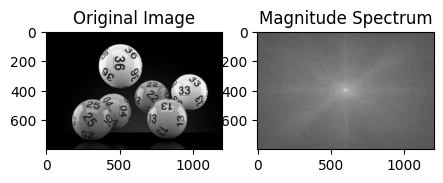

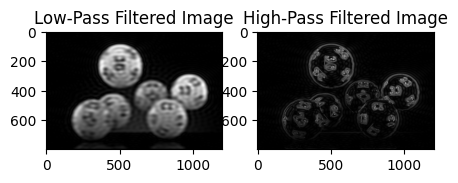

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('/content/img.jpg', cv2.IMREAD_GRAYSCALE)

# Check if the image was loaded successfully
if image is None:
    print("Error: Could not load image. Please check the file path.")
else:
    # Perform 2D FFT
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)  # Shift zero frequency to center
    magnitude_spectrum = np.abs(fshift)

    # Visualize the spectrum
    plt.figure(figsize=(5, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')

    plt.subplot(1, 2, 2)
    plt.imshow(np.log(magnitude_spectrum + 1), cmap='gray')
    plt.title('Magnitude Spectrum')
    plt.show()

    # Apply Low-pass filter (Ideal)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.zeros((rows, cols), np.uint8)
    r = 30  # Radius of low-pass filter
    center = [crow, ccol]
    x, y = np.ogrid[:rows, :cols]
    mask_area = (x - center[0])**2 + (y - center[1])**2 <= r**2
    mask[mask_area] = 1
    fshift_lp = fshift * mask

    # Apply High-pass filter (Ideal)
    mask_hp = np.ones((rows, cols), np.uint8)
    mask_hp[mask_area] = 0
    fshift_hp = fshift * mask_hp

    # Inverse FFT to get filtered images
    img_back_lp = np.fft.ifft2(np.fft.ifftshift(fshift_lp))
    img_back_hp = np.fft.ifft2(np.fft.ifftshift(fshift_hp))

    # Plot the results
    plt.figure(figsize=(5, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(np.abs(img_back_lp), cmap='gray')
    plt.title('Low-Pass Filtered Image')

    plt.subplot(1, 2, 2)
    plt.imshow(np.abs(img_back_hp), cmap='gray')
    plt.title('High-Pass Filtered Image')
    plt.show()

Displaying the last frame and motion mask:


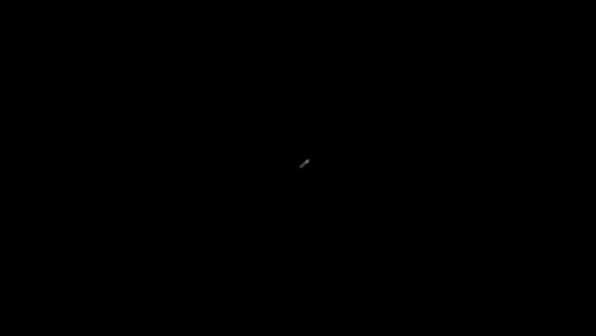

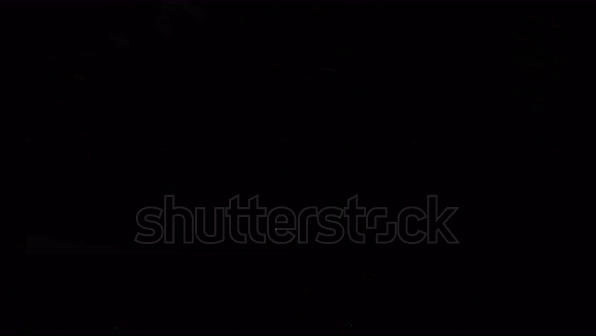

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# Initialize video capture
cap = cv2.VideoCapture('/content/stock-footage-a-firework-display-in-seconds.webm')

# Check if video opened successfully
if not cap.isOpened():
    print("Error: Could not open video file.")
    exit()

# Read the first frame
ret, prev_frame = cap.read()
prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

last_frame = None
last_mask = None

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Convert current frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Compute the absolute difference between current and previous frame
    frame_diff = cv2.absdiff(prev_gray, gray)

    # Apply threshold
    _, motion_mask = cv2.threshold(frame_diff, 50, 255, cv2.THRESH_BINARY)

    # Blur to reduce noise
    motion_mask = cv2.GaussianBlur(motion_mask, (5, 5), 0)

    # Store the last processed frames
    last_frame = frame
    last_mask = motion_mask

    # Update previous frame
    prev_gray = gray

cap.release()

# Display only the last frame and mask
if last_frame is not None and last_mask is not None:
    print("Displaying the last frame and motion mask:")
    cv2_imshow(last_mask)
    cv2_imshow(last_frame)
else:
    print("No frames were processed.")

cv2.destroyAllWindows()
